# 1장 3강: 데이터 특성에 따른 가설검정 기법 선택 — 실습문제

## 실습 목표

- 비교할 변수의 척도와 집단 관계를 확인할 수 있다.
- Shapiro-Wilk 검정으로 정규성을 확인할 수 있다.
- Levene 검정으로 등분산성을 확인할 수 있다.
- 가정 점검 결과에 따라 독립표본 t검정과 Welch t검정을 선택할 수 있다.
- 선택한 검정의 p-value를 해석하여 데이터에 근거한 결론을 작성할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- scipy.stats
- `ames_housing.csv`

| 컬럼 | 의미 | 유형 |
|---|---|---|
| `SalePrice` | 주택 판매가격 | 연속형 |
| `KitchenQual` | 주방 품질 | 범주형·순서형 |
| `HeatingQC` | 난방 품질 | 범주형·순서형 |

> 모든 판단의 유의수준은 `α = 0.05`입니다.  
> 표본 추출에는 `random_state=42`를 사용하여 실행할 때마다 같은 결과가 나오도록 합니다.


## 실습 준비

1. pandas와 `scipy.stats`를 불러오세요.
2. Ames Housing 데이터를 `df`에 불러오세요.
3. 데이터 크기, 전체 결측치 수, 컬럼명과 상위 5개 행을 확인하세요.

In [1]:
# 실습 준비 코드를 작성하세요.

import pandas as pd
import scipy.stats

df = pd.read_csv("ames_housing.csv")

df.describe()
print(df.shape)

(1460, 10)


In [2]:
df.isna().sum()

SalePrice       0
GrLivArea       0
LotArea         0
OverallQual     0
KitchenQual     0
CentralAir      0
HeatingQC       0
PavedDrive      0
Neighborhood    0
YearBuilt       0
dtype: int64

---

## 필수 1. 정규성은 충족하지만 등분산성이 위반된 경우

### 문제 1-1. 주방 품질 `Gd`와 `TA` 집단의 판매가격 비교

#### 문제 설명

주방 품질이 `Gd`(Good)인 주택과 `TA`(Typical/Average)인 주택의 판매가격을 비교하려고 합니다. 각 집단에서 30개씩 표본을 추출한 뒤 정규성과 등분산성을 확인하고 적절한 t검정 방법을 선택하세요.

#### 요구사항

1. `KitchenQual == "Gd"`인 주택의 `SalePrice`에서 30개를 추출해 `group_gd`에 저장하세요.
2. `KitchenQual == "TA"`인 주택의 `SalePrice`에서 30개를 추출해 `group_ta`에 저장하세요.
3. 두 집단의 표본 수와 평균을 확인하세요.
4. 각 집단에 Shapiro-Wilk 정규성 검정을 수행하세요.
5. 두 집단에 Levene 등분산 검정을 수행하세요.
6. 각 가정의 p-value를 0.05와 비교하여 충족 여부를 판단하세요.
7. 다음 규칙에 따라 t검정 방법을 선택하세요.
   - 두 집단 모두 정규성 충족 + 등분산성 충족: 독립표본 t검정
   - 두 집단 모두 정규성 충족 + 등분산성 위반: Welch t검정
8. 선택한 검정을 실행하고 검정통계량과 p-value를 출력하세요.
9. 두 집단의 판매가격 차이가 통계적으로 유의한지 해석하세요.

#### 해석 질문

**Q1.** Shapiro-Wilk 검정의 귀무가설은 무엇인가요?  
**Q2.** Levene 검정의 귀무가설은 무엇인가요?  
**Q3.** 가정 점검 결과 어떤 t검정 방법을 선택해야 하나요?  
**Q4.** 선택한 검정의 결과에 따르면 두 집단의 판매가격 차이는 유의한가요?

#### 제출 결과

- 집단별 표본 수와 평균
- 정규성 및 등분산성 검정 결과
- t검정 방법 선택과 선택 근거
- 최종 검정통계량과 p-value
- 결과 해석
- Q1~Q4 답변


In [3]:
# 필수 1 코드를 작성하세요.
from scipy import stats


group_gd = df[df["KitchenQual"] == "Gd"]["SalePrice"].sample(30, random_state=42)
group_ta = df[df["KitchenQual"] == "TA"]["SalePrice"].sample(30, random_state=42)
print(group_gd.count(), group_gd.mean())
print(group_ta.count(), group_ta.mean())

stat_gd, p_gd = stats.shapiro(group_gd)
stat_ta, p_ta = stats.shapiro(group_ta)

print(f"Gd: W={stat_gd:.4f}, p={p_gd:.4f}")
print(f"TA: W={stat_ta:.4f}, p={p_ta:.4f}")

alpha = 0.05
print("Gd 정규성 만족" if p_gd > alpha else "Gd 정규성 불만족")
print("TA 정규성 만족" if p_ta > alpha else "TA 정규성 불만족")

stat_lev, p_lev = stats.levene(group_gd, group_ta)
print(f"Levene: 통계량={stat_lev:.4f}, p={p_lev:.4f}")

alpha = 0.05
print("등분산 만족" if p_lev > alpha else "등분산 불만족")

for name, p in [("Gd 정규성", p_gd), ("TA 정규성", p_ta), ("등분산성", p_lev)]:
    print(f"{name}: p={p:.4f} →", "충족" if p > alpha else "불충족")

30 190591.06666666668
30 133586.66666666666
Gd: W=0.9348, p=0.0661
TA: W=0.9669, p=0.4571
Gd 정규성 만족
TA 정규성 만족
Levene: 통계량=6.0628, p=0.0168
등분산 불만족
Gd 정규성: p=0.0661 → 충족
TA 정규성: p=0.4571 → 충족
등분산성: p=0.0168 → 불충족


### 필수 1 답변 작성란

- **Q1.** Shapiro-Wilk 검정의 귀무가설은 무엇인가요?
-> 표본이 나온 모집단의 분포가 정규분포이다
-> p-value가 0.05이하면 이 가설을 기각하고 정규성 위반 근거가 있다고 본다.  
- **Q2.**
-> 두 집단의 분산이 같다
-> 두 집단의 가격이 각 집단 평균 주변에 흩어진 정도가 같은지 확인한다.
- **Q3.**
-> welch t검정을 선택, 정규성 위반 근거는 없고
-> Levene P-value가 0.017로 등분산성 위반 근거가 있다.
- **Q4.**
-> 네. Welch t검정의 p-value가 약 0.05보다 작으므로 두 집단의 모집단 평균 판매가격이 같다는 귀무가설을 기각한다.

---

## 필수 2. 정규성과 등분산성이 모두 충족된 경우

### 문제 2-1. 난방 품질 `TA`와 `Fa` 집단의 판매가격 비교

#### 문제 설명

난방 품질이 `TA`(Typical/Average)인 주택과 `Fa`(Fair)인 주택의 판매가격을 비교하려고 합니다. 각 집단에서 20개씩 표본을 추출한 뒤 정규성과 등분산성을 확인하고 적절한 t검정 방법을 선택하세요.

#### 요구사항

1. `HeatingQC == "TA"`와 `HeatingQC == "Fa"`인 집단에서 `SalePrice`를 20개씩 추출하세요.
2. 두 집단의 표본 수와 평균을 확인하세요.
3. 두 집단이 독립집단인지 대응집단인지 판단하세요.
4. 각 집단에 Shapiro-Wilk 정규성 검정을 수행하세요.
5. 두 집단에 Levene 등분산 검정을 수행하세요.
6. 두 집단 모두 정규성을 충족하는지 확인하세요.
7. 등분산성 결과에 따라 독립표본 t검정 또는 Welch t검정 중 적절한 방법을 선택하세요.
8. 선택한 검정을 실행하고 검정통계량과 p-value를 출력하세요.
9. 두 집단의 판매가격 차이가 통계적으로 유의한지 해석하세요.

#### 해석 질문

**Q1.** 두 집단은 독립집단인가요, 대응집단인가요?  
**Q2.** 두 집단의 정규성 가정은 충족되나요?  
**Q3.** 두 집단의 등분산성 가정은 충족되나요?  
**Q4.** 가정 점검 결과 어떤 t검정 방법을 선택해야 하나요?  
**Q5.** 최종 검정 결과는 무엇을 의미하나요?

#### 제출 결과

- 집단별 표본 수와 평균
- 집단 관계 판단
- 정규성 및 등분산성 검정 결과
- t검정 방법과 선택 근거
- 검정통계량과 p-value
- 결과 해석
- Q1~Q5 답변


TA : n=20, 평균=130,845.0, 표준편차=42,357.0
Fa : n=20, 평균=122,855.0, 표준편차=47,973.0
평균 차이(TA-Fa) = 7,990.0

[집단 유형] 서로 다른 집에서 뽑았고 짝지을 근거가 없음 → 독립집단

[Shapiro] TA : W=0.9736, p=0.8290
[Shapiro] Fa : W=0.9319, p=0.1681

[Levene] 통계량=1.3104, p=0.2595 → 등분산 만족
[정규성] 두 집단 모두 충족

[독립표본 t검정] t=0.5584, p=0.5799

→ p ≥ 0.05 : 귀무가설을 기각하지 못함. 두 집단의 평균 차이가 유의하다고 보기 어렵다.


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

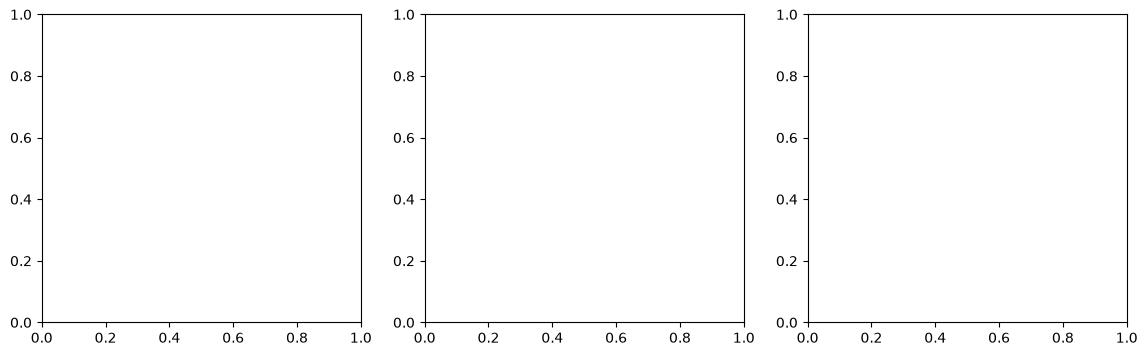

In [6]:
# 필수 2 코드를 작성하세요.
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ALPHA = 0.05
df = pd.read_csv("ames_housing.csv")

# 1. 두 집단에서 20개씩 추출
ta = df.loc[df["HeatingQC"] == "TA", "SalePrice"].sample(n=20, random_state=42)
fa = df.loc[df["HeatingQC"] == "Fa", "SalePrice"].sample(n=20, random_state=42)

# 2. 표본 수와 평균
print(f"TA : n={ta.size}, 평균={ta.mean():,.1f}, 표준편차={ta.std():,.1f}")
print(f"Fa : n={fa.size}, 평균={fa.mean():,.1f}, 표준편차={fa.std():,.1f}")
print(f"평균 차이(TA-Fa) = {ta.mean()-fa.mean():,.1f}")

# 3. 독립집단 / 대응집단 판단
print("\n[집단 유형] 서로 다른 집에서 뽑았고 짝지을 근거가 없음 → 독립집단")

# 4. Shapiro-Wilk 정규성 검정
sw_ta = stats.shapiro(ta)
sw_fa = stats.shapiro(fa)
print(f"\n[Shapiro] TA : W={sw_ta.statistic:.4f}, p={sw_ta.pvalue:.4f}")
print(f"[Shapiro] Fa : W={sw_fa.statistic:.4f}, p={sw_fa.pvalue:.4f}")

# 5. Levene 등분산 검정
lev = stats.levene(ta, fa, center="median")
equal_var = lev.pvalue > ALPHA
print(f"\n[Levene] 통계량={lev.statistic:.4f}, p={lev.pvalue:.4f}"
      f" → {'등분산 만족' if equal_var else '등분산 위배'}")

# 6. 정규성 종합 판정
normal_ok = (sw_ta.pvalue > ALPHA) and (sw_fa.pvalue > ALPHA)
print("[정규성] 두 집단 모두 충족" if normal_ok else "[정규성] 위배된 집단 있음")

# 7-8. 검정 선택 후 실행
method = "독립표본 t검정" if equal_var else "Welch t검정"
t_res = stats.ttest_ind(ta, fa, equal_var=equal_var)
print(f"\n[{method}] t={t_res.statistic:.4f}, p={t_res.pvalue:.4f}")

if not normal_ok:
    mw = stats.mannwhitneyu(ta, fa, alternative="two-sided")
    print(f"[보조] Mann-Whitney U={mw.statistic:.4f}, p={mw.pvalue:.4f}")

# 9. 해석
if t_res.pvalue < ALPHA:
    higher = "TA" if ta.mean() > fa.mean() else "Fa"
    print(f"\n→ p < {ALPHA} : 귀무가설 기각. 두 집단의 판매가격 차이는 "
          f"통계적으로 유의하며 {higher} 집단이 더 높다.")
else:
    print(f"\n→ p ≥ {ALPHA} : 귀무가설을 기각하지 못함. "
          "두 집단의 평균 차이가 유의하다고 보기 어렵다.")

# 시각적 확인
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].boxplot([ta, fa], labels=["TA", "Fa"])
axes[0].set_title("SalePrice by HeatingQC")
stats.probplot(ta, dist="norm", plot=axes[1]); axes[1].set_title("Q-Q : TA")
stats.probplot(fa, dist="norm", plot=axes[2]); axes[2].set_title("Q-Q : Fa")
plt.tight_layout()
plt.show()

### 필수 2 답변 작성란

- **Q1.**
-> 필수 2번에서는 독립집단, 서로 다른 주택을 비교하여
-> 같은 주택의 리모델링 전후처럼 관측값이 짝을 이루는 대응집단이 아님
- **Q2.**
-> 두 집단 모두 Shapiro p-value가 0.05보다 크므로 정규성 위반 근거가 부족하다.
- **Q3.**
-> Levene p-value가 약 0.259이므로 0.05보다 크므로 등분산성 위반 근거가 부족하다
- **Q4.**
-> 실습의 선택 기준에 따라 등분산을 가정한 독립표본 t검정을 선택합니다.
- **Q5.**
-> p-value가 약 0.58이므로 0.05보다 크다.
-> 평균의 차이가 통계적으로 유의하지 않다.
-> 필수 2번에서 정규성과 등분산성의 위반 근거가 없으면 등분산을 가정한 독립표본 t 

---

## 과제. 난방 품질에 따른 t검정 방법 선택

### 문제 3-1. 난방 품질 `Ex`와 `TA` 집단의 판매가격 비교

#### 문제 설명

난방 품질이 `Ex`(Excellent)인 주택과 `TA`(Typical/Average)인 주택의 판매가격을 비교하려고 합니다. 각 집단에서 20개씩 표본을 추출한 뒤 필수 문제에서 학습한 **독립표본 t검정과 Welch t검정 선택 과정**을 독립적으로 적용하세요.

#### 요구사항

1. `HeatingQC == "Ex"`인 집단과 `HeatingQC == "TA"`인 집단에서 `SalePrice`를 20개씩 추출하세요.
2. 두 집단의 표본 수와 평균을 출력하세요.
3. 두 집단이 독립집단인지 대응집단인지 판단하세요.
4. 각 집단의 정규성과 두 집단의 등분산성을 검정하세요.
5. 두 집단 모두 정규성을 충족하는지 확인하세요.
6. 등분산성 결과에 따라 독립표본 t검정 또는 Welch t검정 중 적절한 방법을 선택하고 선택 이유를 작성하세요.
7. 선택한 검정을 실행하여 검정통계량과 p-value를 출력하세요.
8. 난방 품질에 따라 판매가격에 유의한 차이가 있는지 결론을 작성하세요.

#### 해석 질문

**Q1.** 두 집단의 정규성 가정은 충족되나요?  
**Q2.** 두 집단의 등분산성 가정은 충족되나요?  
**Q3.** 최종적으로 어떤 t검정 방법을 선택해야 하나요?  
**Q4.** 검정 결과 난방 품질에 따른 판매가격 차이는 통계적으로 유의한가요?

#### 제출 결과

- 표본 구성과 집단 관계 판단
- 정규성 및 등분산성 검정 결과
- 최종 t검정 선택과 근거
- 검정통계량과 p-value
- 결과 해석
- Q1~Q4 답변


In [1]:
# 과제 코드를 작성하세요.

import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('ames_housing.csv')

# 1. 각 집단에서 20개씩 표본 추출
ex = df.loc[df['HeatingQC'] == 'Ex', 'SalePrice'].dropna().sample(20, random_state=42)
ta = df.loc[df['HeatingQC'] == 'TA', 'SalePrice'].dropna().sample(20, random_state=42)

# 2. 표본 수와 평균
print(f"Ex 집단 : n = {len(ex)}, 평균 = {ex.mean():,.2f}")
print(f"TA 집단 : n = {len(ta)}, 평균 = {ta.mean():,.2f}")

# 4. 정규성 검정 (Shapiro-Wilk)
w1, p1 = stats.shapiro(ex)
w2, p2 = stats.shapiro(ta)
print(f"\n[정규성] Ex : W = {w1:.4f}, p = {p1:.4f}")
print(f"[정규성] TA : W = {w2:.4f}, p = {p2:.4f}")

# 4. 등분산성 검정 (Levene)
lev, p_lev = stats.levene(ex, ta)
print(f"[등분산성]  : W = {lev:.4f}, p = {p_lev:.4f}")

# 6~7. 등분산성 결과에 따라 검정 선택
equal_var = p_lev > 0.05
name = "독립표본 t검정(Student)" if equal_var else "Welch t검정"
t_stat, p_val = stats.ttest_ind(ex, ta, equal_var=equal_var)

print(f"\n선택한 검정 : {name}")
print(f"t 통계량    : {t_stat:.4f}")
print(f"p-value     : {p_val:.6f}")

Ex 집단 : n = 20, 평균 = 259,451.20
TA 집단 : n = 20, 평균 = 130,845.00

[정규성] Ex : W = 0.9447, p = 0.2939
[정규성] TA : W = 0.9736, p = 0.8290
[등분산성]  : W = 6.9271, p = 0.0122

선택한 검정 : Welch t검정
t 통계량    : 4.9073
p-value     : 0.000049


### 과제 답변 작성란

- **Q1.** 두 집단의 정규성 가정은 충족되나요? 
-> 둘 다 정규성 가정은 충족한다. Shapiro-Wilk 검정에서 p가 각각 0.2939, 0.8290으로 둘 다 0.05보다 크다.
-> 정규성 검정은 '정규분포를 따른다'가 귀무가설이므로 p가 크면 귀무가설을 기각하지 못해 정규성을 가정할 수 있다.

- **Q2.** 두 집단의 등분산성 가정은 충족되나요?
-> 충족하지 않는디. p = 0.0122로 0.05보다 작아 두 집단의 분산이 같다는 귀무가설이 기각된다.

- **Q3.** 최종적으로 어떤 t검정 방법을 선택해야 하나요?
-> welch의 t검정. 정규성은 충족하고 등분산성만 위배되었으므로 자유도를 보정하는 welch t 검정이 적절하다. 

- **Q4.** 검정 결과 난방 품질에 따른 판매가격 차이는 통계적으로 유의한가요?
-> 유의하다. p-value 값이 0.000049로 0.05보다 훨씬 작다. 난방 품질 Ex 집단과 TA 집단의 평균 판매 가격 차이 약 128,606 달러는 우연으로 보기 어렵다.

---

## 실습 마무리

1. 두 집단을 비교하기 전에 어떤 데이터 특성을 먼저 확인해야 하나요?
-> 비교할 값은 판매가격처럼 수치형 변수인지, 두 집단은 독립, 대응인지 확인해야 한다.

2. 정규성 검정과 등분산 검정에서 `p > 0.05`는 무엇을 의미하나요?
-> Shapiro 검정은 정규성, Levene 검정은 등분산성, 마지막 t검정은 두 모집단의 평균 차이를 확인하다.

3. 두 집단 모두 정규성을 충족하고 등분산성도 충족하면 어떤 검정을 사용할 수 있나요?
-> 정규성, 등분산성 검정에서 p >  0.05이면 해당 가정의 위반 근거가 부족하다라는 뜻
-> 가정이 참이라고 증명된 것은 아님
-> 독립표본 t검ㅈ정을 선택한다.

4. 두 집단 모두 정규성을 충족하지만 등분산성이 위반되면 어떤 검정을 사용할 수 있나요?
-> welch t검정을 선택한다.

5. 독립표본 t검정과 Welch t검정을 선택할 때 정규성과 등분산성을 함께 확인해야 하는 이유는 무엇인가요?
-> 정규성 평균에 퍼짐 정도 일반적으로 예상이 가능한 범주
-> 등분산성 두 집단 사이가 얼마나 유사한지
